In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

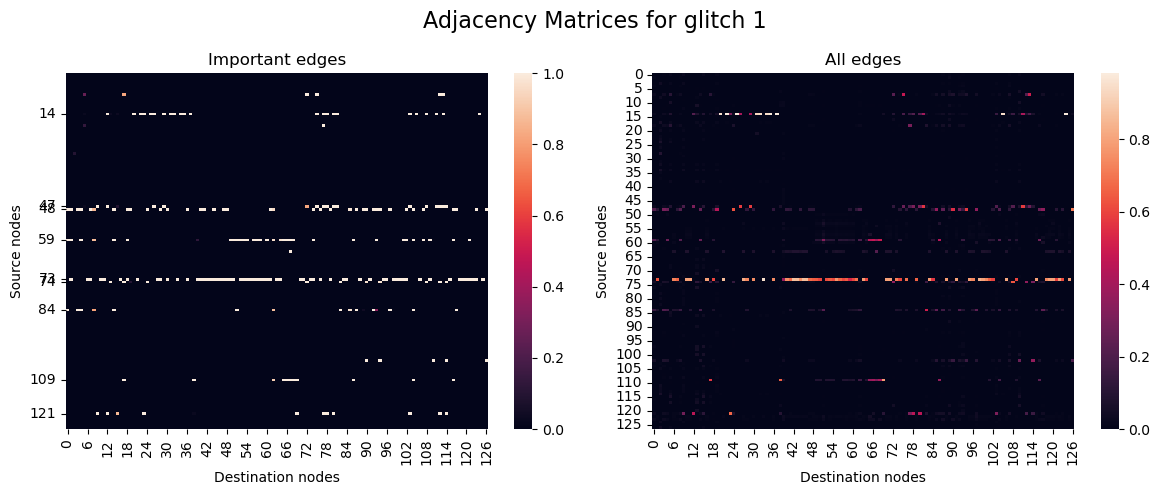

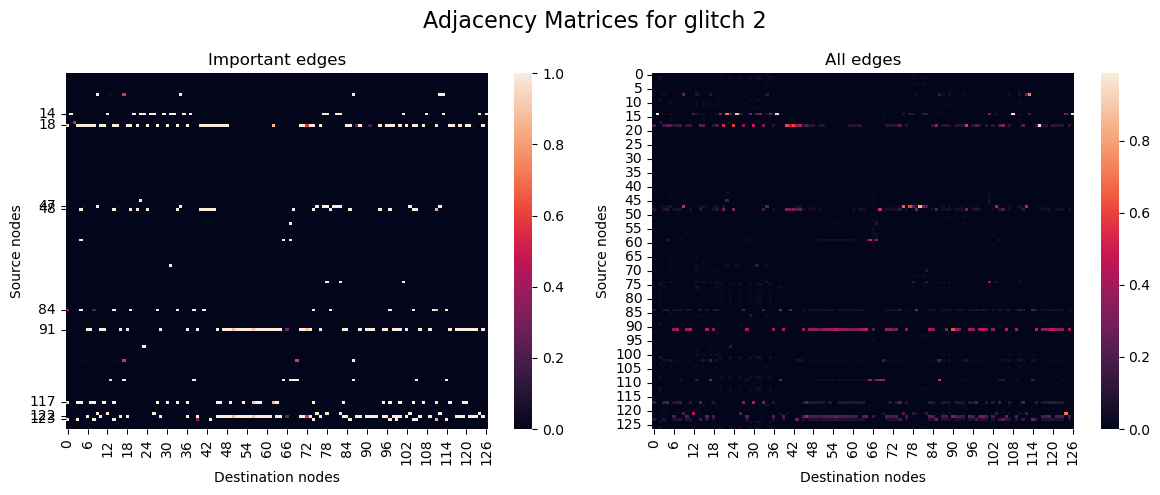

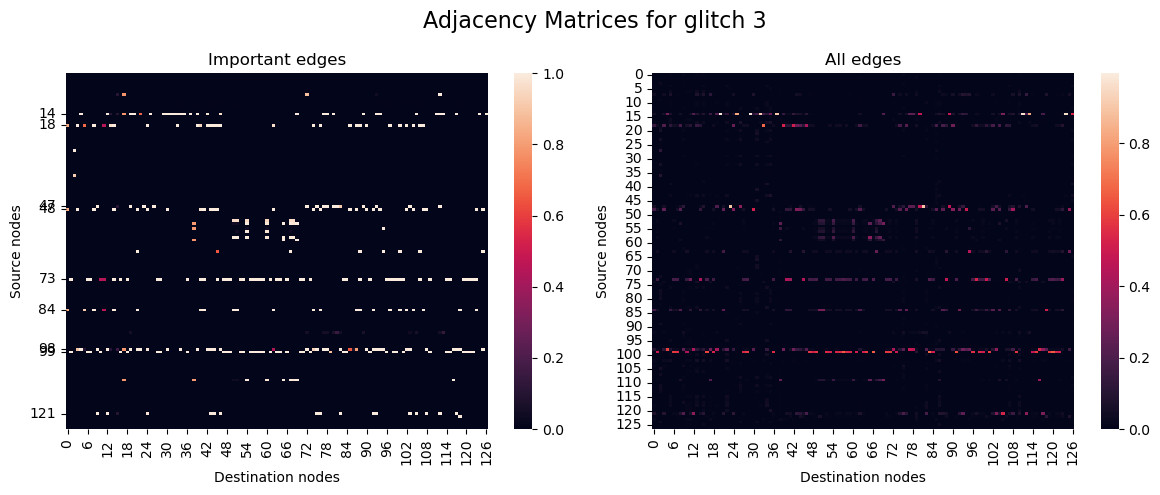

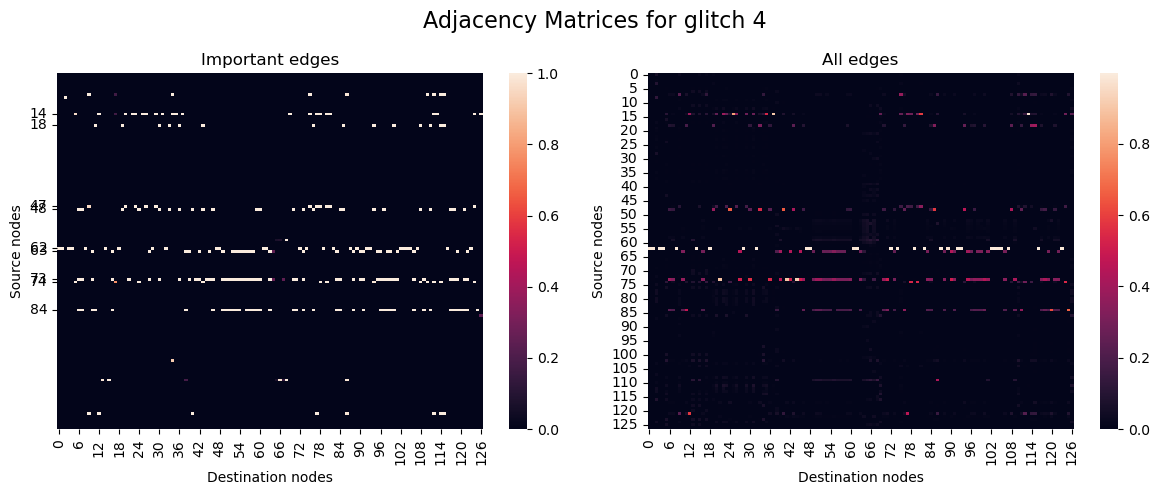

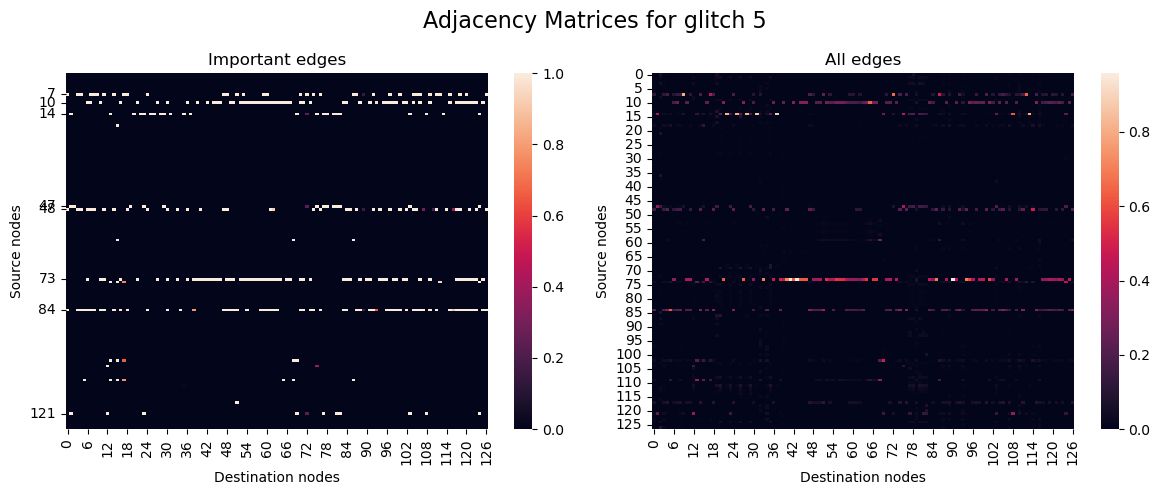

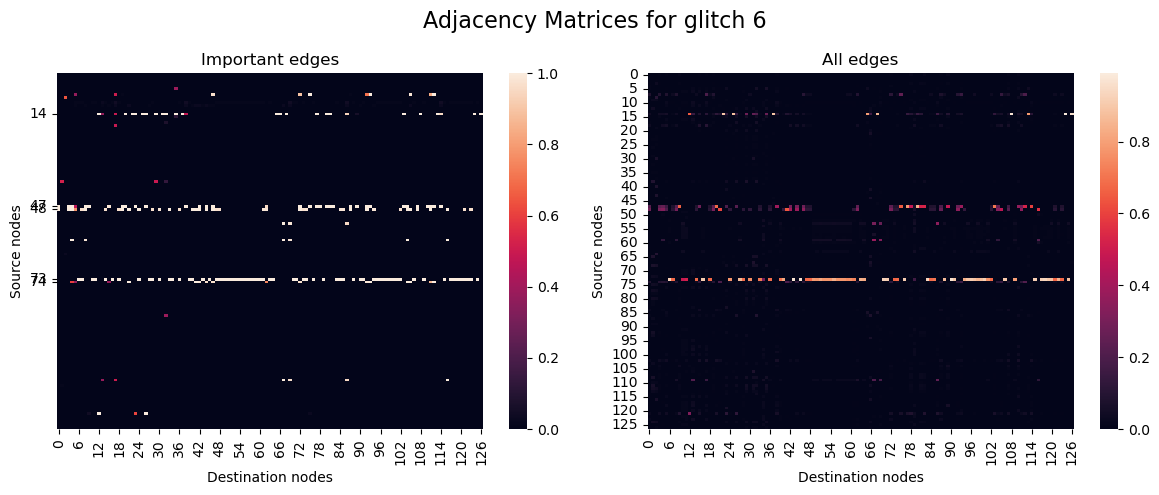

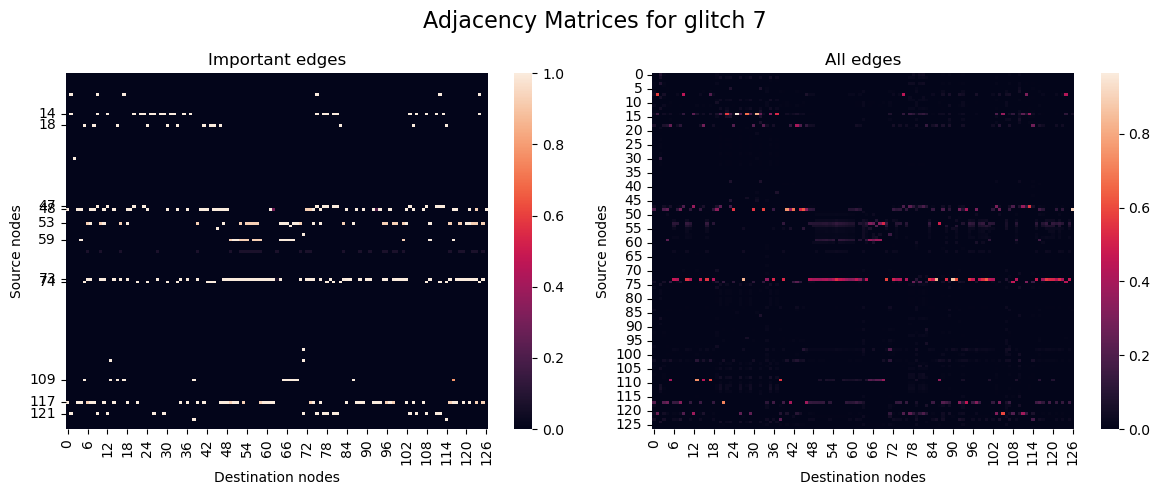

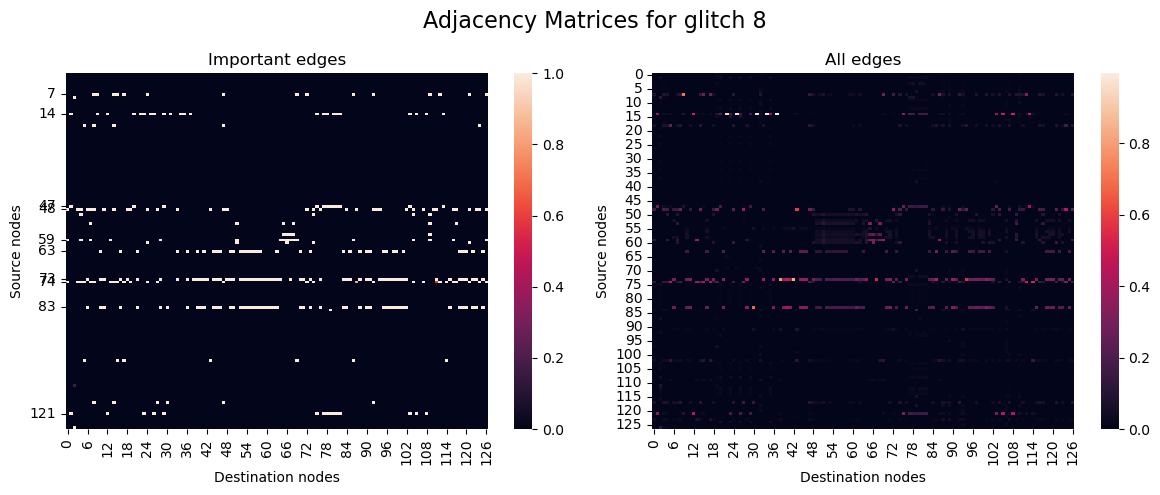

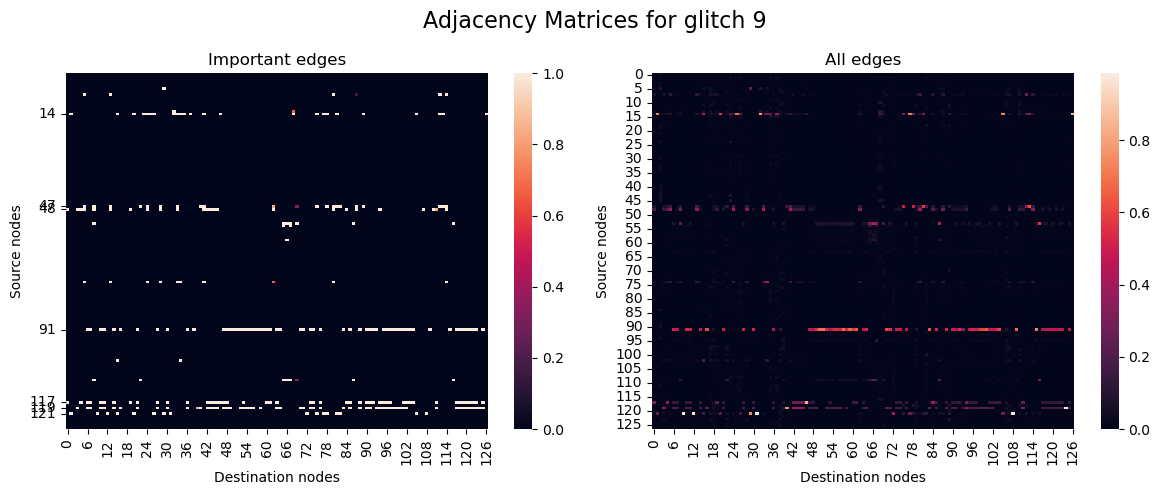

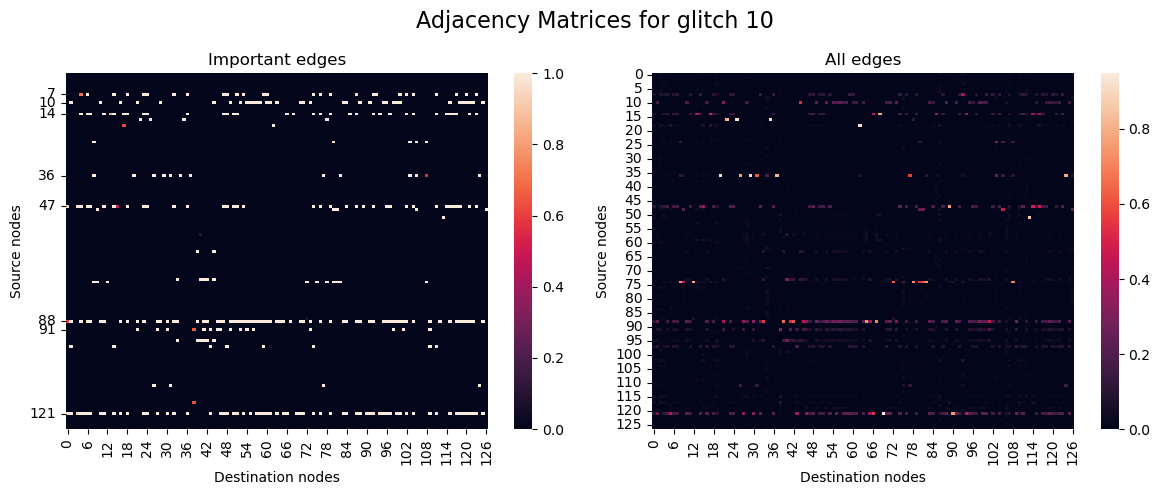

In [2]:
glitch_id = [1,2,3,4,5,6,7,8,9,10]
mask = 0.1
for i in glitch_id:
    temp_at = torch.load(f"./attention_weights/glitch_{i}.pt", weights_only=False)
    att_weights = []
    edges = []
    big_weights = []
    
    for j in range(0,len(temp_at)-1):
        att_weights.append(np.array(temp_at[j]['layers'][0]['attention_weights'].squeeze(-1).squeeze(-1)))
        big_weights.append(np.array(temp_at[j]['layers'][0]['attention_weights'].squeeze(-1).squeeze(-1)) > mask)
        edges.append(temp_at[j]['layers'][0]['edge_index'])

    a = np.sum(att_weights, axis = 0)/len(att_weights)
    b = np.sum(big_weights, axis = 0)/len(big_weights)
    big_adj = np.zeros((127,127))
    adj = np.zeros(shape = (127,127))
    src = edges[0][0]
    dst = edges[0][1]

    for k in range(0, len(a)):
        adj[src[k], dst[k]] = a[k]
        big_adj[src[k], dst[k]] = b[k]

    # Compute important source nodes -- to determine which ticks to show
    imp = np.sum(big_adj, axis=1)
    above_10_imp = np.where(imp > 10)[0]

    

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- First heatmap ---
    sns.heatmap(big_adj, ax=axes[0])
    axes[0].set_title("Important edges")
    axes[0].set_xlabel("Destination nodes")
    axes[0].set_ylabel("Source nodes")

    # only show ticks for those source nodes
    axes[0].set_yticks(above_10_imp + 0.5)  # +0.5 to center tick labels
    axes[0].set_yticklabels(above_10_imp)

    # --- Second heatmap ---
    sns.heatmap(adj, ax=axes[1])
    axes[1].set_title("All edges")
    axes[1].set_xlabel("Destination nodes")
    axes[1].set_ylabel("Source nodes")

    fig.suptitle(f"Adjacency Matrices for glitch {i}", fontsize=16)
    plt.tight_layout()
    plt.savefig(f'./imgs/adj_mat/adj_mat_glitch_{i}')
    plt.show()
    



In [127]:
imp = np.sum(big_adj, axis=1)
nonzero_imp = np.nonzero(imp)[0]
above_10_imp = np.where(imp > 10)[0]
print(nonzero_imp)
print(above_10_imp)
print(imp)

[  7  14  18  30  47  48  53  54  55  57  59  63  73  74  98 102 109 117
 121 123]
[ 14  18  47  48  53  59  73  74 109 117 121]
[ 0.          0.          0.          0.          0.          0.
  0.          6.          0.          0.          0.          0.
  0.          0.         25.          0.          0.          0.
 13.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         14.
 40.29090909  0.          0.          0.          0.         35.47272727
  1.          1.          0.          1.          0.         17.41818182
  0.          0.          0.          2.25454545  0.          0.
  0.          0.          0.          0.          0.          0.
  0.         57.07272727 15.          0.          0.          0.
  0.      